In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)

   ---------------------------------------- 0/3 [contourpy]
   ---------------------------------------- 0/3 [contourpy]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ACER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Importing and understanding the dataset

In [ ]:
# Read the dataset
df =pd.read_csv("student_habits_performance.csv")

In [5]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


Which habits most impact students’ performance?

In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='str')

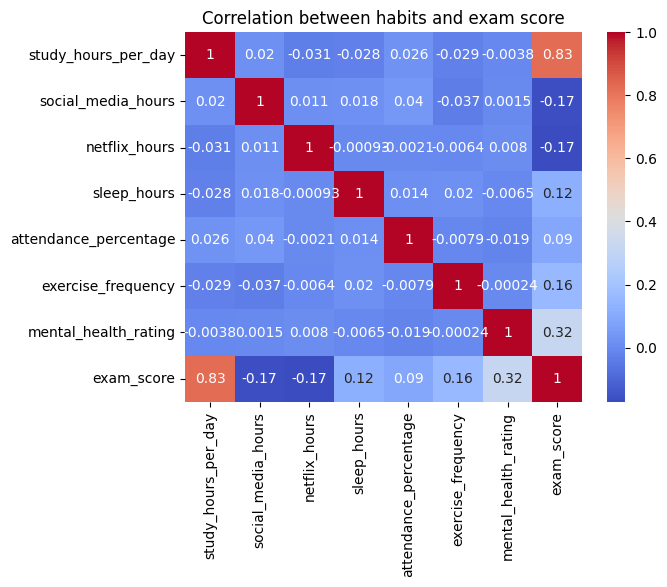

In [10]:
# Filter the dataset to keep only the numeric columns
cols = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "sleep_hours",
    "attendance_percentage",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score",
    
]
# Plot the correlation heatmap
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between habits and exam score")
plt.show()

Do students who study more perform better?

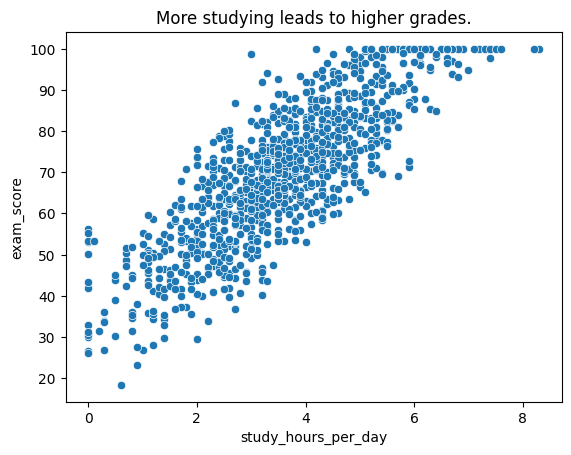

In [11]:
# Dispersion plot for study hours vs exam score
sns.scatterplot(data=df, x="study_hours_per_day", y="exam_score")
plt.title("More studying leads to higher grades.")
plt.show()

In [12]:
# Comparing the average between students who study >5h x who study <2h
filter_study_hard = df["study_hours_per_day"] > 5
filter_study_light = df["study_hours_per_day"] < 2

group_study_hard = df[filter_study_hard]["exam_score"]
group_study_light = df[filter_study_light]["exam_score"]  
print("Average exam score for students who study more than 5 hours:", group_study_hard.mean())
print("Average exam score for students who study less than 2 hours:", group_study_light.mean())

Average exam score for students who study more than 5 hours: 90.79419354838709
Average exam score for students who study less than 2 hours: 45.56390977443609


Does time spent on social media impact students’ academic performance?

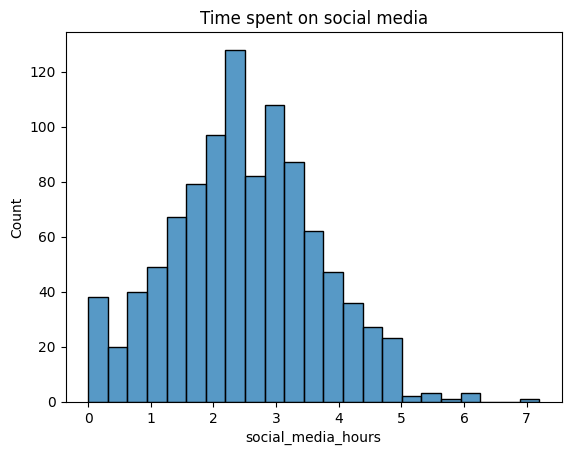

In [16]:
# Social medias (historgrama)
sns.histplot(data=df, x="social_media_hours")
plt.title("Time spent on social media")
plt.show()

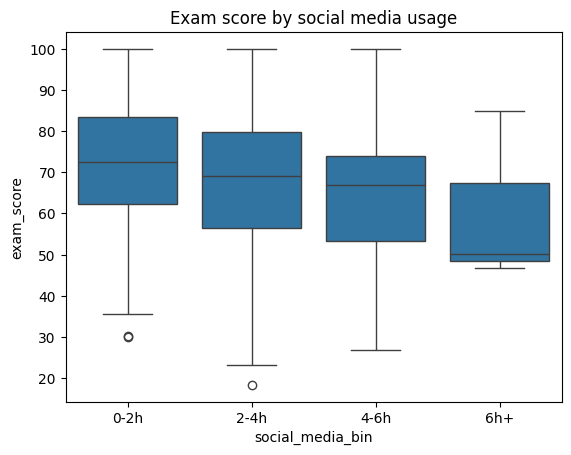

In [17]:
# Check average grades in different bins (0-2h, 2-4h, 4-6h, 6+)

df["social_media_bin"] = pd.cut(
    df["social_media_hours"],
    bins=[0, 2, 4, 6, np.inf],
    labels=["0-2h", "2-4h", "4-6h", "6h+"]  
)

# Plot bloxplot
sns.boxplot(data=df, x="social_media_bin", y="exam_score")
plt.title("Exam score by social media usage")
plt.show()

Does mental health influence students’ performance?

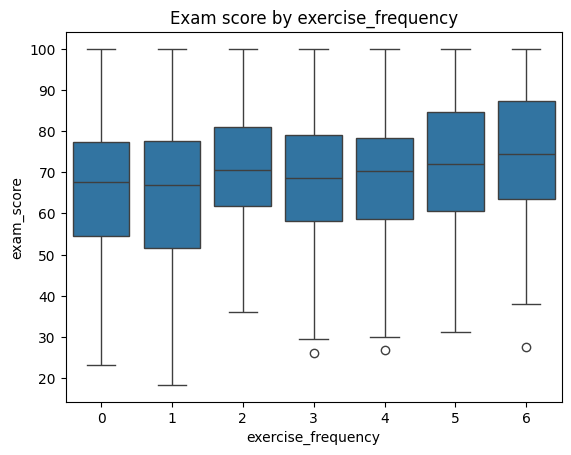

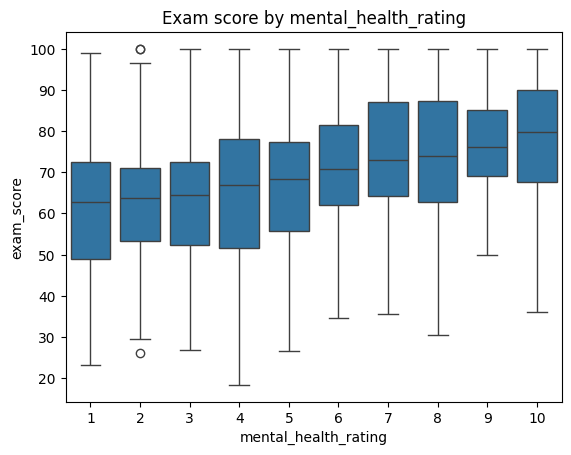

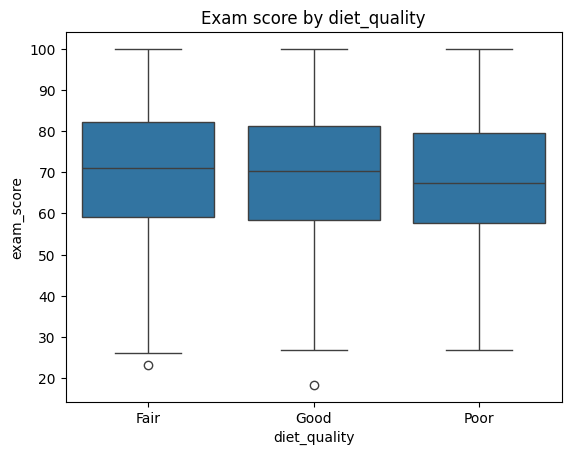

In [18]:
# Exercise frequency 
for col in ["exercise_frequency", "mental_health_rating", "diet_quality"]:
    sns.boxplot(data=df, x=col, y="exam_score")
    plt.title(f"Exam score by {col}")
    plt.show()

Is there a difference in grades between men and women?

In [19]:
# Statistics by gender (average and standard deviation)
df.groupby(["gender"])["exam_score"].agg(["mean", "std"])

,mean,std
gender,,
Female,69.741372,16.899351
Male,69.368344,17.150875
Other,70.647619,13.755890


In [22]:
df["gender"].value_counts(normalize=True)

gender
Female    0.481
Male      0.477
Other     0.042
Name: proportion, dtype: float64